# ✅ 11주차 복습과제: Word2Vec 복습과 RNN/CNN을 이용한 Sentence Classification
- 이번 복습과제는 다음과 같이 이루어져있습니다.
  1. Word2Vec 복습 (VanillaSkipGram)
  2. RNN으로 문장 분류
  3. CNN으로 문장 분류

### **1. Word2Vec Skip-gram 모델 구현**

In [1]:
#라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import defaultdict
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

- 기존 corpus에서 문장 추가

In [2]:
#corpus(말뭉치) 만들기 -> 직접 새로운 말뭉치를 만들어봐도 좋습니다! (* 문장 추가)
corpus = [
    "he likes cat", "she likes dog", "dog barks", "cat meows",
    "he walks the dog", "she feeds the cat", "the cat sleeps on the sofa",
    "the dog plays in the yard", "they both like animals", "animals are friends",
    "cats are cute", "dogs are the best", "she plays with the cat", "she is not afraid of animals",
    "dogs love to run", "cats like to hide", "he trains the dog", "the cat follows her",
    "the cat jumps on the table", "the dog chases a ball", "the cat watches birds", "the dog guards the house",
    "the dog is friendly", "the cat feels sleepy", "cats are curious", "dogs are adorable",
    "the dog barks loudly", "dogs love bones", "the cat meows softly", "the cat  climbs the curtain"
]

In [3]:
# 단어 사전 구축
word_list = set(" ".join(corpus).split()) # corpus의 모든 문장을 합치고 공백 기준으로 나누고 set으로 중복 제거
word_to_ix = {word: i for i, word in enumerate(word_list)}
ix_to_word = {i: word for word, i in word_to_ix.items()}
vocab_size = len(word_to_ix)

In [4]:
print(f"단어 개수: {vocab_size}")

단어 개수: 57


In [5]:
# context-target 쌍 만들기
def make_context_target(corpus, window_size=1):
    pairs = []
    for sentence in corpus:
        words = sentence.split()
        for i, word in enumerate(words):
            # 중심 단어 word를 기준으로 윈도우 사이즈만큼 left, right 경계 설정
            left = max(i - window_size, 0)
            right = min(i + window_size + 1, len(words))
            # pairs에 context 수집
            for j in range(left, right):
                if i != j: # 중심단어 자신은 제외 ex. (dogs, dogs) 등
                    pairs.append((word, words[j]))
    return pairs

pairs = make_context_target(corpus)

def word_to_tensor(word):
    return torch.tensor([word_to_ix[word]], dtype=torch.long)

In [6]:
#VanillaSkipgram 정의
class VanillaSkipgram(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        output = self.linear(embeddings)
        return output

In [7]:
#Cross Entropy Loss, Adam Optimizer(learning rate = 0.01)를 사용하세요
embedding_dim = 10
model = VanillaSkipgram(vocab_size, embedding_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [8]:
for epoch in range(200):
    total_loss = 0
    for center, context in pairs:
        center_tensor = word_to_tensor(center)
        context_tensor = word_to_tensor(context)
        optimizer.zero_grad()
        outputs = model(center_tensor)
        loss = criterion(outputs, context_tensor)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 20, Loss: 282.2511
Epoch 40, Loss: 274.7473
Epoch 60, Loss: 271.2573
Epoch 80, Loss: 268.7235
Epoch 100, Loss: 266.8731
Epoch 120, Loss: 265.4154
Epoch 140, Loss: 264.4099
Epoch 160, Loss: 263.7501
Epoch 180, Loss: 262.9111
Epoch 200, Loss: 262.1925


In [9]:
# 결과 확인
word = "dogs"  #다른 단어로 바꿔서 확인해볼 수도 있습니다
word_tensor = word_to_tensor(word)
embedding = model.embedding(word_tensor)
print(f"'{word}'의 임베딩 벡터:")
print(embedding)

'dogs'의 임베딩 벡터:
tensor([[ 2.5793e-02, -5.8857e-02, -8.9138e-04, -8.9570e-02, -2.3069e-01,
         -2.1209e+00, -4.4296e-01, -1.6646e+00, -1.8062e-01,  7.9601e-01]],
       grad_fn=<EmbeddingBackward0>)


In [11]:
# 결과 확인
word = "cats"
word_tensor = word_to_tensor(word)
embedding = model.embedding(word_tensor)
print(f"'{word}'의 임베딩 벡터:")
print(embedding)

'cats'의 임베딩 벡터:
tensor([[ 0.0642,  0.0700, -0.0863, -0.1057, -0.2076,  0.5503,  0.7774, -1.6866,
         -1.8637,  0.1236]], grad_fn=<EmbeddingBackward0>)


In [10]:
dogs_vec = model.embedding(word_to_tensor("dogs")).detach().squeeze(0)
cats_vec = model.embedding(word_to_tensor("cats")).detach().squeeze(0)

print("dogs 벡터 L2 norm:", torch.norm(dogs_vec).item())
print("cats 벡터 L2 norm:", torch.norm(cats_vec).item())

dogs 벡터 L2 norm: 2.863067626953125
cats 벡터 L2 norm: 2.703960657119751


### 유사 단어 확인해보기
  

- 코사인 유사도 이용

In [32]:
def most_similar(word, top_n):
  target_vec = model.embedding(word_to_tensor(word)).detach()
  sims = {}
  for w in word_to_ix:
    if w == word:
      continue
    vectors = model.embedding(word_to_tensor(w)).detach()
    cos_sim = torch.cosine_similarity(target_vec, vectors)
    sims[w] = cos_sim.item()
  return sorted(sims.items(), key=lambda x: x[1], reverse=True)[:top_n]

word = "dogs"
print(f"{word}와 비슷한 단어 top 5: ", most_similar(word, 5))

dogs와 비슷한 단어 top 5:  [('bones', 0.7669141292572021), ('ball', 0.3999495506286621), ('to', 0.3695521354675293), ('curious', 0.35407549142837524), ('softly', 0.3476810157299042)]


In [13]:
word = "cats"
print(f"{word}와 비슷한 단어 top 5: ", most_similar(word, 5))

cats와 비슷한 단어 top 5:  [('animals', 0.7547256946563721), ('curious', 0.6753835082054138), ('cute', 0.6729378700256348), ('friends', 0.6640215516090393), ('adorable', 0.6610541939735413)]


In [14]:
word = "dog"
print(f"{word}와 비슷한 단어 top 5: ", most_similar(word, 5))
word = "cat"
print(f"{word}와 비슷한 단어 top 5: ", most_similar(word, 5))

dog와 비슷한 단어 top 5:  [('loudly', 0.7629416584968567), ('friendly', 0.5240164995193481), ('with', 0.46630823612213135), ('she', 0.458246648311615), ('in', 0.43767857551574707)]
cat와 비슷한 단어 top 5:  [('softly', 0.6514173150062561), ('sleepy', 0.5904107689857483), ('birds', 0.5868626832962036), ('on', 0.5206854939460754), ('her', 0.5189211368560791)]


### TSNE로 시각화하기

- 단어 목록 중 처음 25개 단어를 대상으로 시각화하기
- TSNE(n_components=2, perplexity=10, max_iter=1000, random_state=0) 로 조정

In [48]:
#시각화하기
embedding_matrix = model.embedding.weight.data.cpu().numpy()

words = list(word_to_ix.keys())[:25]
vectors = np.array([embedding_matrix[word_to_ix[word]] for word in words])

tsne = TSNE(n_components=2, perplexity=10, max_iter=1000, random_state=0)
reduced = tsne.fit_transform(vectors)

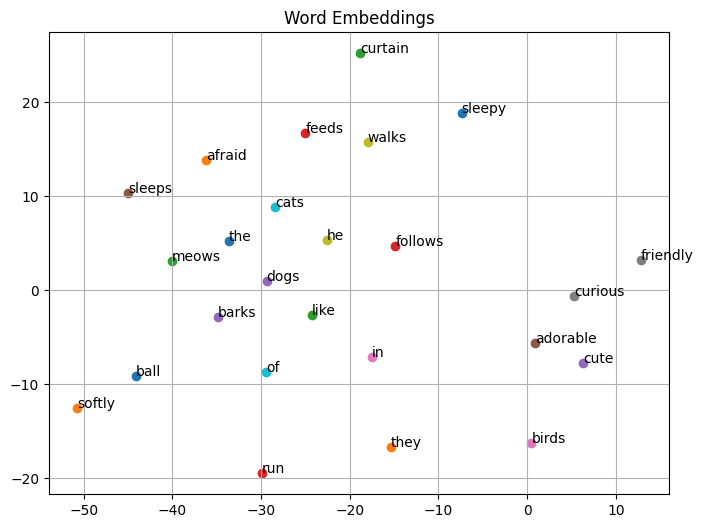

In [49]:
plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)
plt.title("Word Embeddings")
plt.grid(True)
plt.show()

### 시각화 분석

---
- 핵심 단어인 dogs와 cats가 중앙에 가깝게 위치하며, 중심적인 의미 축을 형성함.
- dogs는 barks, like와 가깝고, cats는 meows, sleeps, feeds와 가깝게 배치되어 단어의 의미적 관계를 구분해 잘 학습함.
- 우측 하단에 friendly, curious, adorable, cute와 같이 형용사들이 군집되어 형용사 중심 클러스터가 뚜렷하게 나타남.
- of, in, the와 같은 기능어가 약하지만 모여 있는 형태를 띔.

**전반적으로 의미 군집 간의 경계가 명확하게 분리되면서
Skip-gram 모델이 단어 간 의미적 관계를 효과적으로 학습한 결과로 해석할 수 있음.**

### **2. RNN을 활용한 문장 분류 모델 구현**

In [50]:
import torch.nn.functional as F

In [51]:
train_data = [
    ("I love this movie", 1),
    ("This film is terrible", 0),
    ("I enjoyed it", 1),
    ("Not good", 0),
    ("This movie was fantastic and inspiring", 1),
    ("Absolutely horrible experience", 0),
    ("What a wonderful story and cast", 1),
    ("The plot was dull and boring", 0),
    ("A truly uplifting journey", 1),
    ("It was a waste of time", 0),
    ("I think they could have done better", 0),
    ("It was really enjoyable", 1),
    ("This became my favorite movie", 1),
    ("I recommended this to all of my friends", 1),
    ("My son could film a better movie than this", 0),
    ("It was underwhelming", 0)
]

In [52]:
# 단어 사전
word_set = set()
for sent, _ in train_data:
    for word in sent.lower().split():
        word_set.add(word)

word_to_ix = {word: i+1 for i, word in enumerate(word_set)}  # 0: padding
vocab_size = len(word_to_ix) + 1

def encode_sentence(sent, max_len=10):
    tokens = [word_to_ix.get(word, 0) for word in sent.lower().split()]
    tokens += [0] * (max_len - len(tokens))
    return torch.tensor(tokens[:max_len])

X = torch.stack([encode_sentence(s) for s, _ in train_data])
y = torch.tensor([label for _, label in train_data])

In [53]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, inputs):
        embeddings = self.embedding(inputs)
        output, hidden = self.rnn(embeddings)
        return self.fc(hidden.squeeze(0))

In [54]:
model = RNNClassifier(vocab_size, embedding_dim=16, hidden_dim=32)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(30):
    optimizer.zero_grad()
    outputs = model(X)
    loss = loss_fn(outputs, y)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

preds = torch.argmax(model(X), dim=1)
print("예측 결과:", preds.tolist())
print("실제 정답:", y.tolist())


Epoch 10, Loss: 0.0149
Epoch 20, Loss: 0.0006
Epoch 30, Loss: 0.0001
예측 결과: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0]
실제 정답: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0]


### **3. CNN을 활용한 문장 분류 모델 구현**

In [56]:
#Conv1d로 정의하세요
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, kernel_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(num_filters, 2)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)  #(B, E, T)
        x = F.relu(self.conv(x))                #(B, F, T-k+1)
        x = self.pool(x).squeeze(2)             #(B, F)
        return self.fc(x)

In [57]:
model = CNNClassifier(vocab_size, embedding_dim=16, num_filters=32, kernel_size=3)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(30):
    optimizer.zero_grad()
    outputs = model(X)
    loss = loss_fn(outputs, y)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

preds = torch.argmax(model(X), dim=1)
print("예측 결과:", preds.tolist())
print("실제 정답:", y.tolist())


Epoch 10, Loss: 0.0344
Epoch 20, Loss: 0.0004
Epoch 30, Loss: 0.0000
예측 결과: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0]
실제 정답: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0]
